### 0) 의존성 설치

In [1]:
!pip -q install "transformers>=4.42.0" "datasets>=2.20.0" "accelerate>=0.33.0" "evaluate>=0.4.2" scikit-learn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.4 MB/s eta 0:00:00


In [2]:
import re, os, random, numpy as np, pandas as pd, torch
import torch.nn.functional as F
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split

from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer

from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, classification_report

from sklearn.utils import resample
from collections import Counter

### 1) 데이터 로드 & 전처리

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
CSV_PATH = "/content/drive/MyDrive/KISIA/project/data/mal_data/final_dataset.xlsx"
df = pd.read_excel(CSV_PATH)
df

,package,code,label
0,forgyp,from setuptools import setup\n\nsetup(\n na...,malicious
1,litellm,\n\nimport json\nimport os\nfrom typing import...,benign
2,ptyprocess,\nimport os\nimport errno\n\nfrom pty import (...,benign
3,filelock,from __future__ import annotations\n\nfrom typ...,benign
4,face,\nfrom __future__ import print_function\n\nimp...,benign
...,...,...,...
2217,networkx-match-ssss,#!/usr/bin/env python\n# -*- coding: utf-8 -*-...,malicious
2218,example-vizsla-tutorial,\nfrom setuptools import setup\nfrom setuptool...,malicious
2219,boogishell6,import setuptools\nfrom setuptools import setu...,malicious
2220,pytabtrust,import os\nimport base64\nfrom urllib.request ...,malicious


In [5]:
df["label"].value_counts()

,count
label,
malicious,1670
benign,552


In [6]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

CODE_COL  = "code"
LABEL_COL = "label"

# 악성/정상 이진 분류
BINARY_CLASSES = ['benign', 'malicious']
BINARY_TO_IDX = {c:i for i,c in enumerate(BINARY_CLASSES)}
NUM_LABELS = len(BINARY_CLASSES)

df["label_norm"] = df[LABEL_COL].astype(str).str.strip()
df = df[df["label_norm"].isin(list(BINARY_TO_IDX.keys()))].copy()

df["label_idx"] = df["label_norm"].map(BINARY_TO_IDX).astype(int)

print("원본 데이터 분포:")
print(df["label_norm"].value_counts())

# 간단 코드 정규화
def simple_normalize(code: str) -> str:
    return str(code).replace("\t","    ").replace("\r\n","\n").replace("\r","\n")
df[CODE_COL] = df[CODE_COL].apply(simple_normalize)

# 분할 (라벨 분포 보존)
from sklearn.model_selection import train_test_split

min_count = df["label_idx"].value_counts().min()
if min_count >= 3:
    train_df, temp_df = train_test_split(
        df, test_size=0.2, random_state=SEED, stratify=df["label_idx"]
    )
    val_df, test_df  = train_test_split(
        temp_df, test_size=0.5, random_state=SEED, stratify=temp_df["label_idx"]
    )
else:
    train_df, temp_df = train_test_split(df, test_size=0.2, random_state=SEED, shuffle=True)
    val_df, test_df  = train_test_split(temp_df, test_size=0.5, random_state=SEED, shuffle=True)

print("\n분할 후 학습/검증/테스트셋 크기:", len(train_df), len(val_df), len(test_df))
print("분할 후 학습 데이터 분포:", train_df["label_norm"].value_counts())

# 학습 데이터 오버샘플링 적용
# 소수 클래스 (정상, label_idx=0)와 다수 클래스 (악성, label_idx=1) 분리
df_minority = train_df[train_df["label_idx"] == 0]
df_majority = train_df[train_df["label_idx"] == 1]

# 소수 클래스 오버샘플링
# 다수 클래스 수에 맞춰 복제
n_samples_majority = len(df_majority)
df_minority_oversampled = resample(df_minority,
                                   replace=True,
                                   n_samples=n_samples_majority,
                                   random_state=SEED)

train_df_balanced = pd.concat([df_majority, df_minority_oversampled])

# 데이터 셔플
train_df_balanced = train_df_balanced.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("오버샘플링 후 학습 데이터 분포:", Counter(train_df_balanced["label_idx"]))
print(f"오버샘플링 후 균형 잡힌 학습 데이터셋 크기: {len(train_df_balanced)}")

원본 데이터 분포:
label_norm
malicious    1670
benign        552
Name: count, dtype: int64

분할 후 학습/검증/테스트셋 크기: 1777 222 223
분할 후 학습 데이터 분포: label_norm
malicious    1336
benign        441
Name: count, dtype: int64
오버샘플링 후 학습 데이터 분포: Counter({0: 1336, 1: 1336})
오버샘플링 후 균형 잡힌 학습 데이터셋 크기: 2672


### 2) Hugging Face Datasets 변환 & 토크나이즈

In [7]:
MODEL_NAME = "microsoft/codebert-base"
MAX_LEN = 512
BATCH = 8
N_EPOCHS = 4
LR = 2e-5

def df_to_hfds(df_):
    rec = df_[[CODE_COL, "label_idx"]].rename(columns={"label_idx":"labels"}).reset_index(drop=True)
    return Dataset.from_pandas(rec)

train_ds = df_to_hfds(train_df)
val_ds   = df_to_hfds(val_df)
test_ds  = df_to_hfds(test_df)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

def tokenize_fn(batch):
    return tokenizer(batch[CODE_COL], truncation=True, max_length=MAX_LEN, padding="max_length")

raw = DatasetDict({"train": train_ds, "validation": val_ds, "test": test_ds})
tok = raw.map(tokenize_fn, batched=True, remove_columns=[CODE_COL])
tok.set_format(type="torch", columns=["input_ids","attention_mask","labels"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Map:   0%|          | 0/1777 [00:00<?, ? examples/s]

Map:   0%|          | 0/222 [00:00<?, ? examples/s]

Map:   0%|          | 0/223 [00:00<?, ? examples/s]

### 3) 모델 학습/평가 (멀티클래스: CrossEntropy)

In [8]:
num_labels = NUM_LABELS
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    return {"accuracy": acc, "macro_precision": p, "macro_recall": r, "macro_f1": f1}

args = TrainingArguments(
    output_dir="/content/runs/codebert-7cwe-multiclass",
    num_train_epochs=N_EPOCHS,
    per_device_train_batch_size=BATCH,
    per_device_eval_batch_size=BATCH,
    learning_rate=LR,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_steps=50,
    seed=SEED,
    report_to="none",
    bf16=torch.cuda.is_available(),
    dataloader_pin_memory=False,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tok["train"],
    eval_dataset=tok["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()
val_metrics = trainer.evaluate()
val_metrics

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/codebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1031977944.py:30: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.006000,0.069610,0.990991,0.982456,0.994012,0.988059
2,0.000200,0.044418,0.990991,0.982456,0.994012,0.988059
3,0.007800,0.043935,0.995495,0.991071,0.997006,0.993994
4,0.000200,0.044775,0.995495,0.991071,0.997006,0.993994


{'eval_loss': 0.043934956192970276,
 'eval_accuracy': 0.9954954954954955,
 'eval_macro_precision': 0.9910714285714286,
 'eval_macro_recall': 0.9970059880239521,
 'eval_macro_f1': 0.9939939939939939,
 'eval_runtime': 9.896,
 'eval_samples_per_second': 22.433,
 'eval_steps_per_second': 2.829,
 'epoch': 4.0}

#### 모델 저장

In [9]:
# ===== 모델 저장 =====

# 구글 드라이브에 저장할 디렉토리 지정
SAVE_DIR = "/content/drive/MyDrive/KISIA/project/mal_model"

import os
os.makedirs(SAVE_DIR, exist_ok=True)

# Trainer 객체로 모델 저장
trainer.save_model(SAVE_DIR)

# 토크나이저 저장
tokenizer.save_pretrained(SAVE_DIR)

print(f"모델과 토크나이저가 {SAVE_DIR} 에 저장되었습니다.")

모델과 토크나이저가 /content/drive/MyDrive/KISIA/project/mal_model 에 저장되었습니다.


#### 모델 로드

In [10]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

SAVE_DIR = "/content/drive/MyDrive/KISIA/project/mal_model"
model = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR)
tokenizer = AutoTokenizer.from_pretrained(SAVE_DIR)

print(f"모델과 토크나이저가 {SAVE_DIR} 에서 로드되었습니다.")

모델과 토크나이저가 /content/drive/MyDrive/KISIA/project/mal_model 에서 로드되었습니다.


### 4) 테스트셋 평가 + 리포트 + 추론

In [11]:
# 테스트셋 성능 평가
eval_args = TrainingArguments(
    output_dir="/tmp/eval",
    per_device_eval_batch_size=BATCH,
    dataloader_pin_memory=False,
    report_to="none"
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    return {"accuracy": acc, "macro_precision": p, "macro_recall": r, "macro_f1": f1}

current_trainer = Trainer(
    model=model,
    args=eval_args,
    eval_dataset=tok["test"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

# Test set prediction
test_results = current_trainer.predict(tok["test"])
test_logits = test_results.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_truth = np.array(tok["test"]["labels"])

test_accuracy = accuracy_score(test_truth, test_preds)
test_f1 = f1_score(test_truth, test_preds, average="macro", zero_division=0)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Macro F1: {test_f1:.4f}")
print(classification_report(test_truth, test_preds, target_names=BINARY_CLASSES, zero_division=0))

/tmp/ipython-input-4142380949.py:16: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  current_trainer = Trainer(


Test Accuracy: 0.9865
Test Macro F1: 0.9822
              precision    recall  f1-score   support

      benign       0.96      0.98      0.97        56
   malicious       0.99      0.99      0.99       167

    accuracy                           0.99       223
   macro avg       0.98      0.99      0.98       223
weighted avg       0.99      0.99      0.99       223



In [12]:
# 추론 함수들

# device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device) # 모델을 설정된 device로 이동

def predict_malicious_simple(code: str):
    """간단한 추론 함수 (512 토큰 이하)"""
    # 토큰화
    enc = tokenizer(code, return_tensors="pt", truncation=True, max_length=MAX_LEN, padding=True)
    enc = {k: v.to(device) for k, v in enc.items()}

    # 모델 추론
    model.eval()
    with torch.no_grad():
        logits = model(**enc).logits[0].cpu()
        probs = F.softmax(logits, dim=-1).numpy()

    # 결과 반환
    idx = int(probs.argmax())
    return {
        "label": BINARY_CLASSES[idx],
        "prob": float(probs[idx]),
        "probs": {BINARY_CLASSES[i]: float(probs[i]) for i in range(NUM_LABELS)},
        "is_malicious": idx == 1  # 1이 malicious
    }

def predict_malicious_windowed(code: str, max_len=MAX_LEN, stride=256):
    """윈도우 기반 추론 함수 (긴 코드용)"""
    # 전체 토큰화
    all_tokens = tokenizer(code, return_tensors="pt", truncation=False, add_special_tokens=True)
    all_ids = all_tokens["input_ids"][0]

    if len(all_ids) <= max_len:
        return predict_malicious_simple(code)

    # 윈도우 나누기
    starts = list(range(0, len(all_ids), max_len - stride))
    logits_accum = []

    model.eval()
    with torch.no_grad():
        for s in starts:
            e = min(s + max_len, len(all_ids))
            ids = all_ids[s:e].unsqueeze(0).to(device)
            attn = torch.ones_like(ids).to(device)

            # 패딩 처리
            if len(ids[0]) < max_len:
                pad_length = max_len - len(ids[0])
                ids = torch.cat([ids, torch.zeros(1, pad_length, dtype=ids.dtype).to(device)], dim=1)
                attn = torch.cat([attn, torch.zeros(1, pad_length, dtype=attn.dtype).to(device)], dim=1)

            out = model(input_ids=ids, attention_mask=attn).logits[0].cpu().numpy()
            logits_accum.append(out)

            if e == len(all_ids):
                break

    # 윈도우별 logits 평균 → softmax
    logits_mean = np.mean(logits_accum, axis=0)
    probs = F.softmax(torch.tensor(logits_mean), dim=-1).numpy()
    idx = int(probs.argmax())

    return {
        "label": BINARY_CLASSES[idx],
        "prob": float(probs[idx]),
        "probs": {BINARY_CLASSES[i]: float(probs[i]) for i in range(NUM_LABELS)},
        "is_malicious": idx == 1  # 1이 malicious
    }

def predict_from_file(file_path: str):
    try:
        with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
            code = f.read()
        return predict_malicious_windowed(code)
    except Exception as e:
        return {"error": str(e)}

# 테스트용 코드 예시
test_code = """
import os
import subprocess

def execute_command(user_input):
    # 위험한 코드: 사용자 입력을 직접 실행
    os.system(user_input)
    subprocess.call(user_input, shell=True)
"""

print("=== 테스트 코드 ===")
print(test_code)
print("\n=== 추론 결과 ===")
result = predict_malicious_windowed(test_code)
print(f"예측 라벨: {result['label']}")
print(f"악성 확률: {result['prob']:.4f}")
print(f"악성 여부: {result['is_malicious']}")
print(f"전체 확률: {result['probs']}")

=== 테스트 코드 ===

import os
import subprocess

def execute_command(user_input):
    # 위험한 코드: 사용자 입력을 직접 실행
    os.system(user_input)
    subprocess.call(user_input, shell=True)


=== 추론 결과 ===
예측 라벨: malicious
악성 확률: 0.9999
악성 여부: True
전체 확률: {'benign': 5.144221358932555e-05, 'malicious': 0.9999485015869141}


In [13]:
test_file_path = "/content/drive/MyDrive/KISIA/project/data/vul_data/examples/command_injection-1.py"
print(f"테스트 파일: {test_file_path}")

try:
    result = predict_from_file(test_file_path)
    if "error" in result:
        print(f"오류: {result['error']}")
    else:
        print(f"예측 라벨: {result['label']}")
        print(f"악성 확률: {result['prob']:.4f}")
        print(f"악성 여부: {result['is_malicious']}")
        print(f"전체 확률: {result['probs']}")
except Exception as e:
    print(f"파일 읽기 오류: {e}")
    print("파일 경로를 확인해주세요.")


테스트 파일: /content/drive/MyDrive/KISIA/project/data/vul_data/examples/command_injection-1.py


Token indices sequence length is longer than the specified maximum sequence length for this model (2299 > 512). Running this sequence through the model will result in indexing errors


예측 라벨: malicious
악성 확률: 1.0000
악성 여부: True
전체 확률: {'benign': 4.4868993427371606e-05, 'malicious': 0.9999551773071289}


In [17]:
# 다양한 코드 예시 테스트
test_cases = [
    {
        "name": "정상 코드",
        "code": """
def hello_world():
    print("Hello, World!")
    return "success"
"""
    },
    {
        "name": "악성 코드 - 명령어 실행",
        "code": """
import os
def dangerous_function(user_input):
    os.system(user_input)
    eval(user_input)
"""
    },
    {
        "name": "악성 코드 - 파일 조작",
        "code": """
import shutil
def delete_files():
    shutil.rmtree("/important/data")
    os.remove("/etc/passwd")
"""
    },
    {
        "name": "정상 코드 - 웹 요청",
        "code": """
import requests
def safe_api_call():
    response = requests.get("https://api.example.com/data")
    return response.json()
"""
    }
]

print("=== 다양한 코드 예시 테스트 ===")
for i, test_case in enumerate(test_cases, 1):
    print(f"\n--- 테스트 {i}: {test_case['name']} ---")
    result = predict_malicious_windowed(test_case['code'])
    print(f"예측: {result['label']} (확률: {result['prob']:.4f})")
    print(f"악성 여부: {'악성' if result['is_malicious'] else '정상'}")
    print(f"코드 미리보기: {test_case['code'].strip()[:100]}...")


=== 다양한 코드 예시 테스트 ===

--- 테스트 1: 정상 코드 ---
예측: malicious (확률: 0.9999)
악성 여부: 악성
코드 미리보기: def hello_world():
    print("Hello, World!")
    return "success"...

--- 테스트 2: 악성 코드 - 명령어 실행 ---
예측: malicious (확률: 0.9999)
악성 여부: 악성
코드 미리보기: import os
def dangerous_function(user_input):
    os.system(user_input)
    eval(user_input)...

--- 테스트 3: 악성 코드 - 파일 조작 ---
예측: malicious (확률: 0.9999)
악성 여부: 악성
코드 미리보기: import shutil
def delete_files():
    shutil.rmtree("/important/data")
    os.remove("/etc/passwd")...

--- 테스트 4: 정상 코드 - 웹 요청 ---
예측: malicious (확률: 0.9999)
악성 여부: 악성
코드 미리보기: import requests
def safe_api_call():
    response = requests.get("https://api.example.com/data")
   ...


Confusion Matrix:
[[ 55   1]
 [  2 165]]


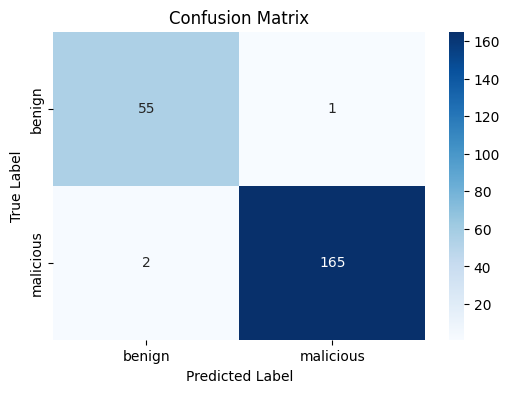

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(test_truth, test_preds)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Optional: Visualize confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=BINARY_CLASSES, yticklabels=BINARY_CLASSES)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()